In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader, TensorDataset

from transformers import PatchTSTConfig, PatchTSTForClassification

from sklearn.preprocessing import StandardScaler
from sklearn import preprocessing
from sklearn.metrics import roc_auc_score, accuracy_score, f1_score, precision_score, recall_score, confusion_matrix
from sklearn.utils.class_weight import compute_class_weight

import math

f:\1D\myj\postG\dataScience\CW\COMP0047-Data-Science-Project\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:

data = pd.read_csv('../../data/labeled_dataset.csv')
data['Date'] = pd.to_datetime(data['Date'])
data['regime_binary']= np.where(data['regime']=='bull',1,0)
data['Risk_Adj_Return_20d'] = data['Return_20d'] / (data['VIX'] + 0.00001)

data['SPY_Volume_20d_MA'] = data['SPY Volume'].rolling(window=20).mean()

data['Relative_Volume'] = data['SPY Volume'] / data['SPY_Volume_20d_MA']

data['MACD_Hist_Accel'] = data['MACD_Hist'] - data['MACD_Hist'].shift(1)

data = data.drop(columns=['SPY_Volume_20d_MA']).dropna()

data['lagged_target_1'] = data['regime_binary'].shift(-1)
data_1 = data.dropna(subset=['lagged_target_1'])

stationary_features = [
    'Return', 'Return_5d', 'Return_20d', 'Return_Smooth', 
    'RSI_14', 'MACD_Hist', 'Drawdown', 
    'VIX', 'VIX_Change', 'VIX_Change_5d', 
    'GDP_YoY', 'Core_Inflation_YoY', 'M2_YoY', 'Unemployment',
    'Risk_Adj_Return_20d','Relative_Volume',
    'MACD_Hist_Accel'
]
X = data_1[stationary_features]
y = data_1['lagged_target_1']

total_rows = len(data_1)

train_end = int(total_rows * 0.70)
val_end = int(total_rows * 0.85) 


scaler = preprocessing.StandardScaler()

X_train = X.iloc[:train_end]
X_train = scaler.fit_transform(X_train)
y_train = y.iloc[:train_end]

X_val = X.iloc[train_end:val_end]
X_val = scaler.transform(X_val)
y_val = y.iloc[train_end:val_end]

X_test = X.iloc[val_end:]
X_test = scaler.transform(X_test)
y_test = y.iloc[val_end:]


In [13]:
print(f"X_train: {X_train.shape}, y_train: {len(y_train)}")
print(f"X_val: {X_val.shape}, y_val: {len(y_val)}")
print(f"X_test: {X_test.shape}, y_test: {len(y_test)}")


SEQ_LEN = 30  

def create_sequences(X, y, seq_len):
    Xs, ys = [], []
    for i in range(len(X) - seq_len + 1):
        Xs.append(X[i:i+seq_len])
        ys.append(y[i+seq_len-1])
    return np.array(Xs), np.array(ys)


train_X_seq, train_y_seq = create_sequences(X_train, y_train.values, SEQ_LEN)
val_X_seq, val_y_seq = create_sequences(X_val, y_val.values, SEQ_LEN)
test_X_seq, test_y_seq = create_sequences(X_test, y_test.values, SEQ_LEN)

print(f"train_X_seq: {train_X_seq.shape}")
print(f"train_y_seq: {train_y_seq.shape}")
print(f"val_X_seq: {val_X_seq.shape}")
print(f"test_X_seq: {test_X_seq.shape}")

# ==================== 3. Dataset & DataLoader ====================
class TimeSeriesDataset(Dataset):
    def __init__(self, X, y):
        self.X = torch.tensor(X, dtype=torch.float32)
        self.y = torch.tensor(y, dtype=torch.long)

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]

batch_size = 64
train_loader = DataLoader(
    TimeSeriesDataset(train_X_seq, train_y_seq),
    batch_size=batch_size,
    shuffle=True
)

val_loader = DataLoader(
    TimeSeriesDataset(val_X_seq, val_y_seq),
    batch_size=batch_size,
    shuffle=False
)

test_loader = DataLoader(
    TimeSeriesDataset(test_X_seq, test_y_seq),
    batch_size=batch_size,
    shuffle=False
)

def feature_dropout(X, p=0.1):
    mask = np.random.binomial(1, 1-p, X.shape)
    return X * mask

# ==================== 5. PatchTST====================
n_features = X_train.shape[1]
print(f"n_features: {n_features}")

config = PatchTSTConfig(
    num_input_channels=n_features, 
    num_targets=2,
    context_length=SEQ_LEN, 
    patch_length=1, 
    stride=1, 
    d_model=64, 
    num_attention_heads=4, 
    num_hidden_layers=2,  
    dropout=0.05, 
    head_dropout=0.05, 
)


model = PatchTSTForClassification(config)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)


weights = compute_class_weight(
    class_weight='balanced',
    classes=np.array([0, 1]),
    y=train_y_seq
)
class_weights = torch.tensor(weights, dtype=torch.float32).to(device)
print(f"weights: {weights}")

def focal_loss(logits, targets, alpha=class_weights, gamma=2.0):
    ce_loss = F.cross_entropy(logits, targets, weight=alpha, reduction='none', label_smoothing=0.05)
    pt = torch.exp(-ce_loss)
    loss = (1 - pt) ** gamma * ce_loss
    return loss.mean()


optimizer = torch.optim.AdamW(
    model.parameters(),
    lr=8e-5,
    betas=(0.9, 0.95),
    weight_decay=5e-3
)

scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode='max',
    factor=0.5,
    patience=3
)

# ==================== train + Early Stopping ====================
EPOCHS = 100
patience = 5

best_auc = 0
trigger = 0
train_losses = []
val_aucs = []

for epoch in range(EPOCHS):
    model.train()
    total_loss = 0
    
    for X_batch, y_batch in train_loader:
        X_batch_np = feature_dropout(X_batch.numpy(), p=0.1)
        X_batch = torch.tensor(X_batch_np, dtype=torch.float32).to(device)
        y_batch = y_batch.to(device)
        
        optimizer.zero_grad()
        
        outputs = model(past_values=X_batch)
        logits = outputs.prediction_logits
        
        loss = focal_loss(logits, y_batch, gamma=2.0)
        loss.backward()
        
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        
        optimizer.step()
        total_loss += loss.item()
    
    avg_train_loss = total_loss / len(train_loader)
    train_losses.append(avg_train_loss)
    
    # ----- eval -----
    model.eval()
    val_probs = []
    val_labels = []
    
    with torch.no_grad():
        for X_batch, y_batch in val_loader:
            X_batch = X_batch.to(device)
            outputs = model(past_values=X_batch)
            logits = outputs.prediction_logits
            probs = torch.softmax(logits, dim=1)[:, 1]
            val_probs.extend(probs.cpu().numpy())
            val_labels.extend(y_batch.numpy())
    
    val_auc = roc_auc_score(val_labels, val_probs)
    val_aucs.append(val_auc)
    
    print(f"Epoch {epoch+1:3d} | Train Loss: {avg_train_loss:.4f} | Val AUC: {val_auc:.4f}")
    
    scheduler.step(val_auc)
    
    # ----- Early Stopping -----
    if val_auc > best_auc:
        best_auc = val_auc
        trigger = 0
        torch.save(model.state_dict(), "best_patchtst.pth")
        best_val_probs = np.array(val_probs)
        best_val_labels = np.array(val_labels)
        print(f"  → new model saved! (AUC: {val_auc:.4f})")
    else:
        trigger += 1
        if trigger >= patience:
            print(f"\nEarly stopping at epoch {epoch+1}")
            break

# ==================== 9. find thresholds====================
thresholds = np.arange(0.05, 0.95, 0.01)
best_score = 0
best_thresh = 0.5

for t in thresholds:
    preds = (best_val_probs >= t).astype(int)
    recall_bear = recall_score(best_val_labels, preds, pos_label=0, zero_division=0)
    recall_bull = recall_score(best_val_labels, preds, pos_label=1, zero_division=0)
    
    score = 0.6 * recall_bear + 0.4 * recall_bull
    
    if score > best_score:
        best_score = score
        best_thresh = t

print(f"\n best_thresh: {best_thresh:.3f} ")



X_train: (5632, 17), y_train: 5632
X_val: (1207, 17), y_val: 1207
X_test: (1207, 17), y_test: 1207
train_X_seq: (5603, 30, 17)
train_y_seq: (5603,)
val_X_seq: (1178, 30, 17)
test_X_seq: (1178, 30, 17)
n_features: 17
weights: [1.20962867 0.85229693]
Epoch   1 | Train Loss: 0.1595 | Val AUC: 0.8593
  → new model saved! (AUC: 0.8593)
Epoch   2 | Train Loss: 0.1389 | Val AUC: 0.8631
  → new model saved! (AUC: 0.8631)
Epoch   3 | Train Loss: 0.1293 | Val AUC: 0.8724
  → new model saved! (AUC: 0.8724)
Epoch   4 | Train Loss: 0.1276 | Val AUC: 0.8736
  → new model saved! (AUC: 0.8736)
Epoch   5 | Train Loss: 0.1226 | Val AUC: 0.8767
  → new model saved! (AUC: 0.8767)
Epoch   6 | Train Loss: 0.1206 | Val AUC: 0.8785
  → new model saved! (AUC: 0.8785)
Epoch   7 | Train Loss: 0.1209 | Val AUC: 0.8611
Epoch   8 | Train Loss: 0.1197 | Val AUC: 0.8778
Epoch   9 | Train Loss: 0.1192 | Val AUC: 0.8829
  → new model saved! (AUC: 0.8829)
Epoch  10 | Train Loss: 0.1176 | Val AUC: 0.8865
  → new model sa


 best_thresh: 0.500 

Accuracy:  0.6477
F1-score (macro): 0.6430
F2-score:  0.5866
Precision: 0.9453
Recall:    0.5358
ROC-AUC:   0.8483
Specificity: 0.9235
False Negative Rate: 0.4642

Confusion Matrix:
[[314  26]
 [389 449]]


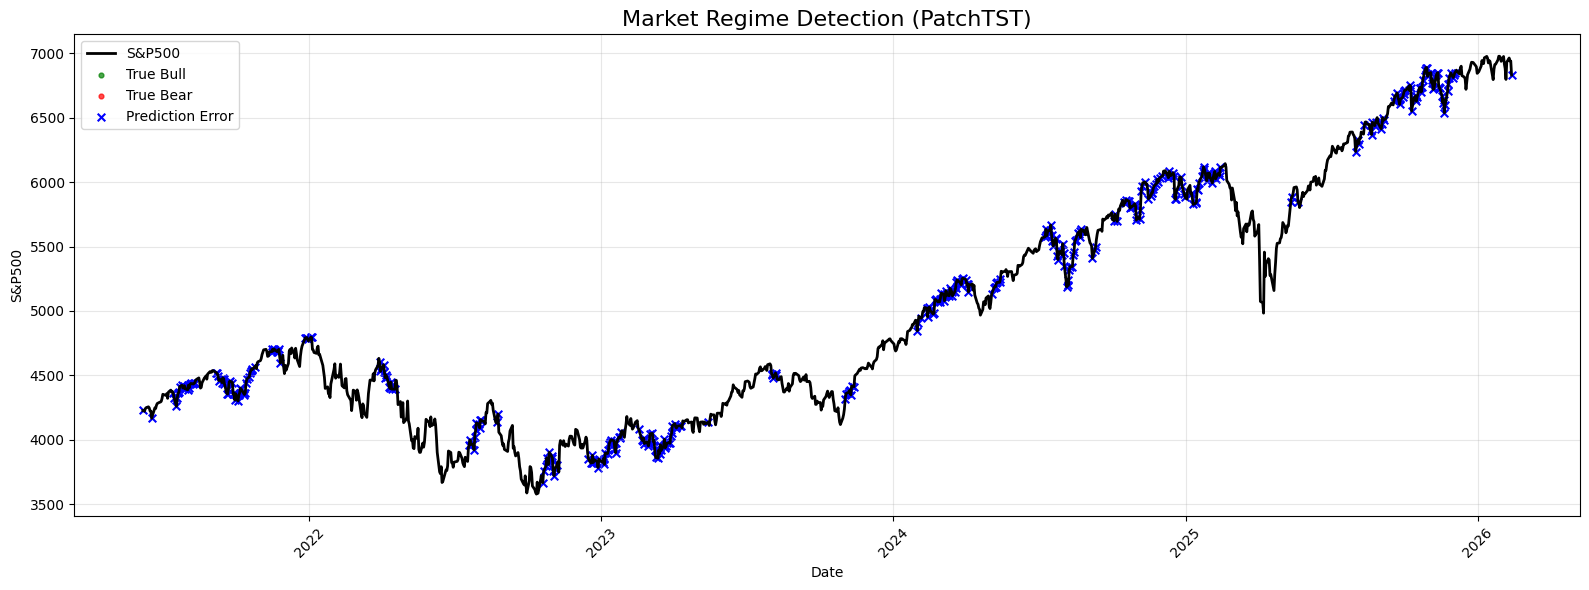

In [14]:
# ==================== evaluation ====================
from sklearn.metrics import fbeta_score

print(f"\n best_thresh: {best_thresh:.3f} ")

model.load_state_dict(torch.load("best_patchtst.pth", map_location=device))
model.eval()


test_probs = []
test_labels = []

with torch.no_grad():
    for X_batch, y_batch in test_loader:
        X_batch = X_batch.to(device)
        outputs = model(past_values=X_batch)
        logits = outputs.prediction_logits
        probs = torch.softmax(logits, dim=1)[:, 1]
        test_probs.extend(probs.cpu().numpy())
        test_labels.extend(y_batch.numpy())

test_probs = np.array(test_probs)
test_preds = (test_probs >= best_thresh).astype(int)


accuracy = accuracy_score(test_labels, test_preds)
f1_macro = f1_score(test_labels, test_preds, average="macro")
f2 = fbeta_score(test_labels, test_preds, beta=2)
precision = precision_score(test_labels, test_preds)
recall = recall_score(test_labels, test_preds)
roc_auc = roc_auc_score(test_labels, test_probs)
cm = confusion_matrix(test_labels, test_preds)
tn, fp, fn, tp = cm.ravel()
fnr = fn / (fn + tp)
specificity = tn / (tn + fp)



print("\n" + "="*50)
print("="*50)
print(f"Accuracy:  {accuracy:.4f}")
print(f"F1-score (macro): {f1_macro:.4f}")
print(f"F2-score:  {f2:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall:    {recall:.4f}")
print(f"ROC-AUC:   {roc_auc:.4f}")
print(f"Specificity: {specificity:.4f}")
print(f"False Negative Rate: {fnr:.4f}")
print("\nConfusion Matrix:")
print(cm)


try:
    test_dates = data_1.iloc[val_end + SEQ_LEN - 1:]['Date'].values[:len(test_labels)]
    sp500_prices = data_1.iloc[val_end + SEQ_LEN - 1:]['GSPC'].values[:len(test_labels)]
    
    plt.figure(figsize=(16, 6))
    
   
    plt.plot(test_dates, sp500_prices, color="black", linewidth=2, label="S&P500")
    
   
    bull_idx = test_labels == 1
    bear_idx = test_labels == 0
    error_idx = test_labels != test_preds
    
    plt.scatter(test_dates[bull_idx], sp500_prices[bull_idx], 
                color="green", s=12, alpha=0.7, label="True Bull")
    plt.scatter(test_dates[bear_idx], sp500_prices[bear_idx], 
                color="red", s=12, alpha=0.7, label="True Bear")
    plt.scatter(test_dates[error_idx], sp500_prices[error_idx], 
                color="blue", s=30, marker='x', label="Prediction Error")
    
    plt.title("Market Regime Detection (PatchTST)", fontsize=16)
    plt.xlabel("Date")
    plt.ylabel("S&P500")
    plt.legend()
    plt.grid(alpha=0.3)
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()
    
except Exception as e:
    print(f"error: {e}")